# SR Tutorial

2026 IAIFI Summer School

Tutorial lead: Jose M Munoz Arias

Professor: Miles Cranmer




# Encoding Physics Into the Search

We saw in the morning what symbolic regression is and how we can use evolutionary search to find equations that fit data. 

In this tutorial, we will focus on how to incorporate some of our physics bias into the search process and model building with the nice interface of PySR.

---

This notebook should be easy to run either on Colab or locally, and the only difference is that Colab will take a minute or two to compile the Julia backend the first time it is used. If you are running locally, make sure you have Julia installed and that PySR can find it. If you are running on Colab, you can just run the cell below to install PySR and its dependencies.

Lets do a bit of plumbing first for the notebook to work in both Colab and local environments.

In [1]:
# Run this before anything imports sympy.
#
# sympy >= 1.14 is a hard requirement.
import importlib.util
import subprocess
import sys

IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "pysr", "sympy>=1.14"], check=True)
    print("done; if the sympy check below fails, restart the runtime and re-run")
else:
    import sympy
    if sympy.__version__ < "1.14":
        raise RuntimeError(f"sympy >= 1.14 is required, found {sympy.__version__}")

In [2]:
import os
os.environ.setdefault("PYTHON_JULIACALL_THREADS", "auto")
os.environ.setdefault("PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION", "no")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import sympy

t0 = time.time()
import pysr
from pysr import PySRRegressor, TemplateExpressionSpec
rng = np.random.default_rng(0)
print(f"pysr {pysr.__version__} imported in {time.time() - t0:.0f}s | sympy {sympy.__version__}")

REPO_URL = ("https://raw.githubusercontent.com/munozariasjm/"
            "sr_tutorial_material/master/01_tutorial")

try:
    from session1_data import *
    print("session1_data imported")
except ImportError:
    print("session1_data not found, downloading from GitHub")
    import urllib.request
    urllib.request.urlretrieve(f"{REPO_URL}/session1_data.py", "session1_data.py")
    from session1_data import *
    print("session1_data downloaded and imported")

ASSETS = Path("assets")

REPRO = dict(deterministic=True, parallelism="serial", verbosity=0, progress=False)

def kink(model):
    """The highest-`score` row, where loss drops most per unit of added complexity."""
    return model.equations_.loc[model.equations_.score.idxmax()]

pysr 1.5.9 imported in 12s | sympy 1.14.0
session1_data imported


## 0. Making sure everything runs

Lets make sure that we are able to run everything while we review the API:

In [3]:
X = 2 * rng.standard_normal((100, 5))
y = 2 * np.cos(X[:, 3]) + X[:, 0] ** 2 - 2

quick = PySRRegressor(binary_operators=["+", "-", "*", "/"],
                      unary_operators=["cos", "exp"],
                      niterations=30,
                      random_state=0,
                      **REPRO)
quick.fit(X, y)
quick.equations_[["complexity", "loss", "score", "equation"]]

,complexity,loss,score,equation
0,1,2.365653e+01,0.000000,1.5903167
1,3,4.717466e+00,0.806184,x0 * x0
2,5,1.793064e+00,0.483673,(x0 * x0) + -1.7100621
3,7,1.746472e+00,0.013164,((x0 * x0) + -1.6366416) * 0.9558945
4,8,4.482661e-01,1.359966,(cos(x3) + (x0 * x0)) + -1.855115
5,10,1.218354e-13,14.466869,(x0 * x0) + ((cos(x3) * 2.0) + -2.0)
6,11,9.588883e-14,0.239481,((x0 * x0) + -2.0) + (cos(x3) + cos(x3))
7,12,5.921317e-14,0.482046,(cos(x3) * 2.0) + (((x0 * x0) - 0.4078367) + -...
8,14,4.553800e-14,0.131298,(((cos(x3) * 2.0) + ((x0 * x0) + -1.3002887)) ...


Custom losses and templates each compile their own code path on first use, so a throwaway fit of each now keeps Problems 2, 3 and 4 fast later.

In [4]:
rng_warm = np.random.default_rng(99)
X2 = rng_warm.standard_normal((30, 2)); y2 = 2.0 * X2[:, 0] + X2[:, 1]
X1 = rng_warm.standard_normal((30, 1)); y1 = 2.0 * X1[:, 0]

prewarm = [
    ("elementwise_loss", X2, y2,
     dict(elementwise_loss="l(prediction, target) = abs(prediction - target)")),
    ("TemplateExpressionSpec", X2, y2,
     dict(expression_spec=TemplateExpressionSpec("f(a) + g(b)", expressions=["f", "g"],
                                                 variable_names=["a", "b"]))),
    ("D() inside a template", X1, y1,
     dict(expression_spec=TemplateExpressionSpec(expressions=["f"], variable_names=["a"],
                                                 combine="df = D(f, 1); df(a)"))),
]

for label, Xw, yw, model_kwargs in prewarm:
    PySRRegressor(binary_operators=["+", "*"], niterations=2, random_state=0,
                  **REPRO, **model_kwargs).fit(Xw, yw)

---

# The tools we have

PySR has many tools for 'injecting' physics into the search process. We will focus on three of them:
- **Custom constraints**: We can define our own constraints to limit the search space. For example, we can constrain the search to only consider equations that are linear or that have a certain number of terms.

- **Custom loss functions**: We can define our own loss function to bias the search towards equations that satisfy some physical property. For example, we can define a loss function that penalizes equations that do not conserve energy.

- **Custom templates**: We can define our own templates to bias the search towards equations that have a certain form. For example, we can define a template that only allows equations that are polynomials of a certain degree.

Lets see how we can use these tools to find equations that fit some data, learning with a couple of physical examples.

---

# Lets see the tools we have

## 1. An oscillator driven up from rest

A colleague hands us a trace from a resonantly driven oscillator and asks what equation produced it. It started at rest, so the amplitude climbs from nothing while the drive feeds it, then dies away once damping wins. There is noise on it, and they only managed to record the first half of the ring-down.

We keep everything past $x = 6$ to ourselves. The search never sees it, so it stays an honest test of whether a fit found the physics or just the data.


180 points to fit on, 120 held back


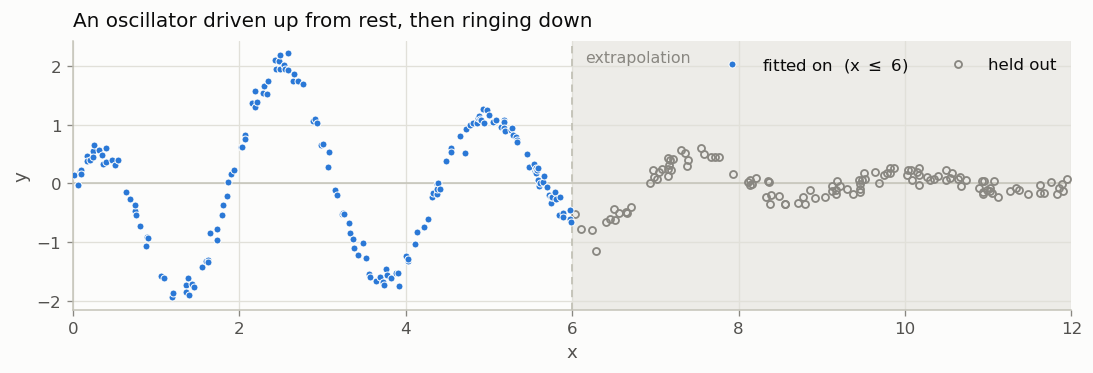

In [5]:
x_fit, y_fit, x_out, y_out = oscillator_data()
X_fit = x_fit.reshape(-1, 1)

print(f"{len(x_fit)} points to fit on, {len(x_out)} held back")
plot_oscillator_data(x_fit, y_fit, x_out, y_out)

### The plain API

Lets review again the API for PySR. 

**The tool — the estimator itself**

```python
model = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],   # two-argument operators
    unary_operators=["sin", "cos", "exp"],   # one-argument operators
    maxsize=25,                              # node budget for one expression
    niterations=40,                          # how long the populations evolve
)
model.fit(X, y, variable_names=["x"])        # X is (n_samples, n_features)
```

`model.equations_` is the Pareto front, one row per complexity. 

`model.get_best()` returns a single row from it, and `model.predict(X)` uses that row unless you pass `index=`.

In [6]:
t = time.time()
unconstrained = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sin", "cos", "exp", "log", "sqrt"],
    maxsize=25,          # largest expression the search may build
    niterations=40,      # how long the populations get to evolve
    **REPRO,
)
unconstrained.fit(X_fit, y_fit, variable_names=["x"])

unconstrained.equations_[["complexity", "loss", "score", "equation"]]

,complexity,loss,score,equation
0,1,1.130147,0.000000,0.052853756
1,3,1.124485,0.002511,x * 0.024740664
2,4,0.238257,1.551731,cos(x * 2.5000672)
3,6,0.149426,0.233273,cos(x * 2.498387) * 1.4297532
4,8,0.138034,0.039650,(cos(x * 2.4918308) * 1.4559224) - 0.11121641
5,9,0.090823,0.418595,exp(cos(log(x))) * cos(x * 2.4986491)
6,10,0.049015,0.616776,(cos(log(x)) + 1.1494335) * cos(x * 2.4996011)
7,11,0.047532,0.030722,cos(x * 2.4995296) * (sin(cos(log(x))) + 1.175...
8,12,0.024053,0.681164,cos(x * 2.4986491) * (cos(0.37685996 - log(x))...
9,13,0.016810,0.358263,(cos(log(x)) + 0.59414345) * (sqrt(x) * cos(x ...


`get_best()` is the row PySR would hand us if we asked for one model: the steepest drop in loss among the rows that are still close to the best fit.

cos(x * 2.4983308) * (sin((sqrt(x) + sqrt(x)) + -1.4172205) + 1.0417179)
nested trig on 1 rows


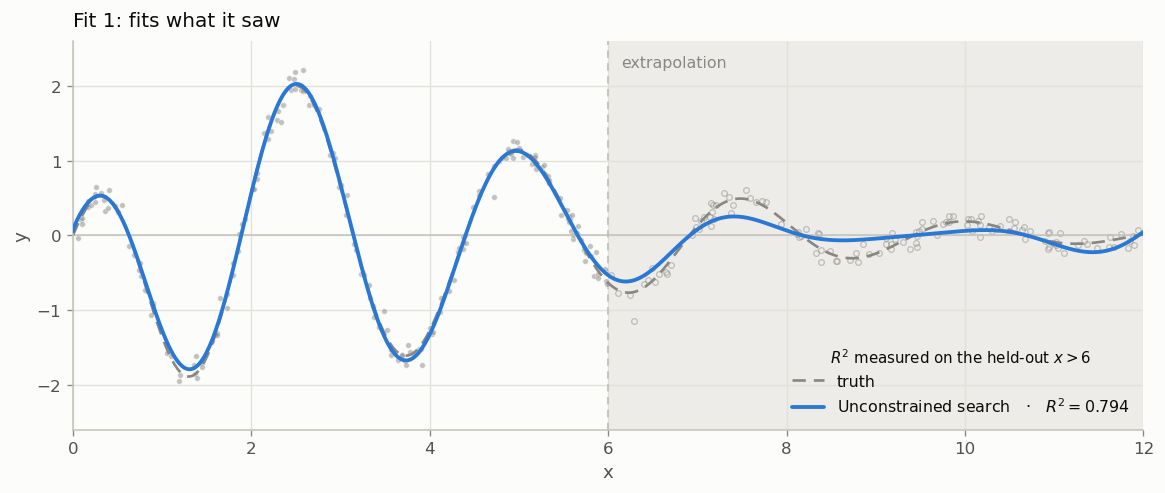

In [7]:
print(unconstrained.get_best().equation)
print(f"nested trig on {unconstrained.equations_.equation.map(has_nested_trig).sum()} rows")

plot_fits([("Unconstrained search", unconstrained)], x_fit, y_fit, x_out, y_out,
          title="Fit 1: fits what it saw")

Do you see any 'problems' with this solution? What would you do to improve it?

### Constraints

Some of the expressions in the front also have expressions with a cosine wrapped inside another cosine. `nested_constraints` says which function may appear inside which, for every expression the search passes through rather than only the survivors.


**The tool — `nested_constraints`**

```python
PySRRegressor(nested_constraints={"cos": {"cos": 0, "exp": 1}}, ...)
```

Read it as: anywhere inside a `cos`, allow zero `cos` and at most one `exp`, at any depth below. Operators you leave out stay unrestricted.

This is a rule about the search space, so it applies to every candidate ever built, not just the ones that survive to the front.

In [8]:
no_nesting = dict(
    nested_constraints={
        "sin": {"sin": 0, "cos": 0},     # no trig inside trig
        "cos": {"sin": 0, "cos": 0},
        "exp": {"exp": 0},
        "log": {"log": 0, "exp": 0},
        "sqrt": {"sqrt": 0},
    },
)

t = time.time()
tidy = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sin", "cos", "exp", "log", "sqrt"],
    maxsize=25, niterations=40, random_state=3, **no_nesting, **REPRO,
)
tidy.fit(X_fit, y_fit, variable_names=["x"])

print(f"{time.time() - t:.0f}s   {len(tidy.equations_)} rows "
      f"(was {len(unconstrained.equations_)}), "
      f"nested trig on {tidy.equations_.equation.map(has_nested_trig).sum()}")
tidy.equations_[["complexity", "loss", "score", "equation"]]

11s   16 rows (was 12), nested trig on 0


,complexity,loss,score,equation
0,1,1.130147,0.000000,0.052885097
1,3,1.124485,0.002511,x * 0.024740636
2,4,0.238257,1.551731,cos(x * 2.500062)
3,6,0.149426,0.233273,cos(x / 0.40026018) * 1.4298296
4,8,0.138034,0.039650,(cos(x * 2.4918168) * 1.4558913) + -0.11123012
5,9,0.091452,0.411689,cos(x / 0.40097183) * (1.376603 - cos(x))
6,10,0.035451,0.947668,(cos(x * 2.4987166) * sin(sqrt(x))) * 1.7877156
7,11,0.025791,0.318125,cos(x / -0.40021402) * (exp(sin(sqrt(x))) + -0...
8,12,0.022148,0.152257,(cos(x / 0.40014598) * sin(sqrt(x) * 1.1044157...
9,13,0.018268,0.192599,((exp(sin(sqrt(x))) + -1.2251358) / 0.761767) ...


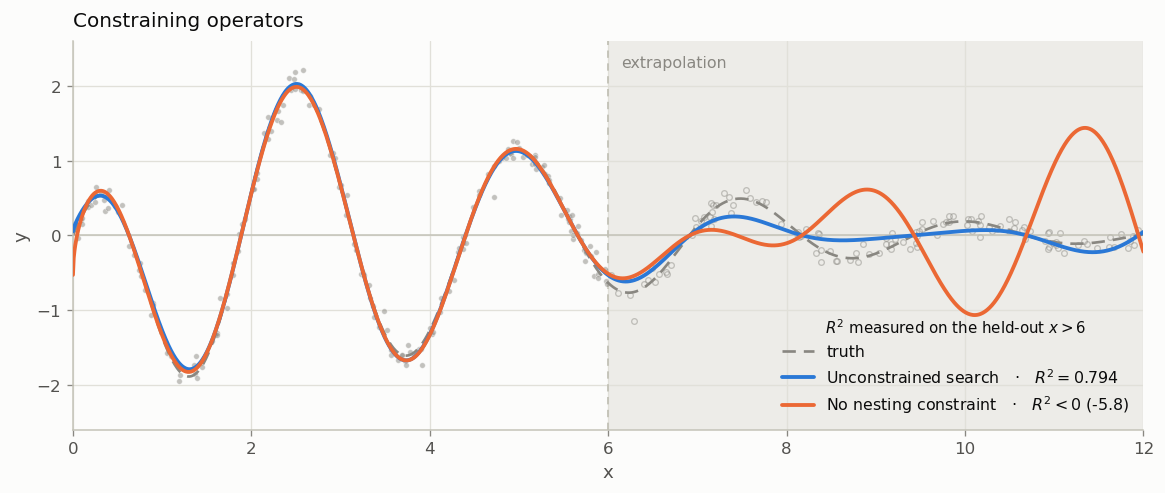

In [37]:
plot_fits([("Unconstrained search", unconstrained), ("No nesting constraint", tidy)],
          x_fit, y_fit, x_out, y_out, title="Constraining operators")

Found faster, with the unphysical terms not appearing.

### The right basis function

We can also bias the search by giving it a basis of functions that we know are physically relevant.

13s   ((x * exp(x * -0.4964409)) * cos((x + -1.2560812) * 2.4971697)) * -2.770538


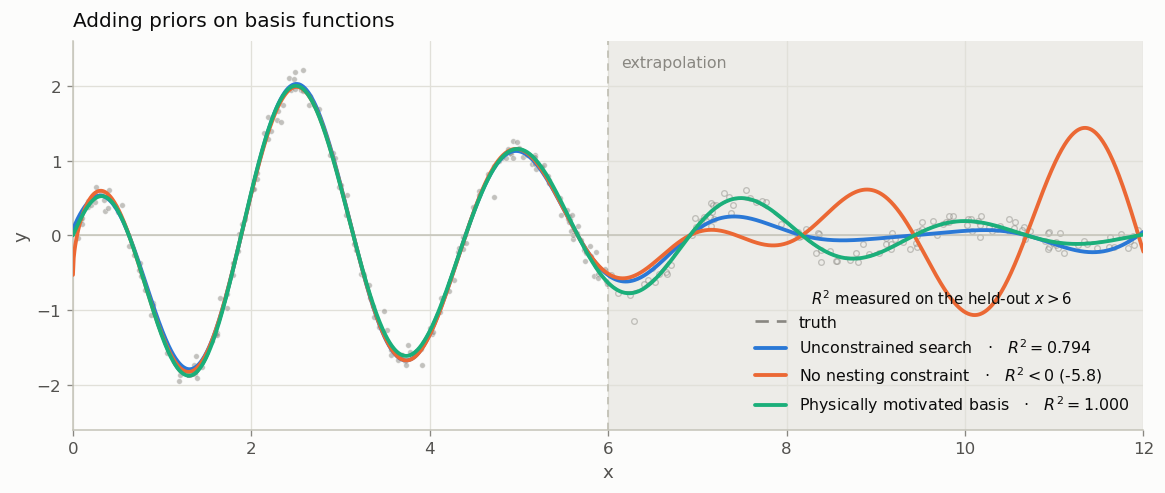

In [40]:
t = time.time()
basis = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["cos", "exp"],          # one oscillation, one envelope, nothing else
    maxsize=25, niterations=40, random_state=3, **REPRO,
    nested_constraints={"cos": {"cos": 0}, "exp": {"exp": 0}},
)
basis.fit(X_fit, y_fit, variable_names=["x"])

print(f"{time.time() - t:.0f}s   {basis.get_best().equation}")
plot_fits([("Unconstrained search", unconstrained), ("No nesting constraint", tidy), ("Physically motivated basis", basis)],
          x_fit, y_fit, x_out, y_out, title="Adding priors on basis functions")

There it is: $2.8\,x\,e^{-x/2}\cos(2.5x)$, which is the ground truth... (set by me, but the search does not know that).

### Physics in the loss instead

Suppose we only knew it is *damped*... And that is a property of the whole function, not just one point.

`elementwise_loss` sees one point at a time, so it cannot express that. `loss_function`: it gets the tree and can evaluate it anywhere we like, including on $x$ far outside the data... so we can use this to penalize functions that do not decay at large $x$.

**The tool — `loss_function`**

```python
LOSS = """
function my_loss(tree, dataset::Dataset{T,L}, options)::L where {T,L}
    prediction, ok = eval_tree_array(tree, dataset.X, options)
    !ok && return L(Inf)                     # candidate failed to evaluate
    return sum((prediction .- dataset.y).^2) / dataset.n
end
"""
PySRRegressor(loss_function=LOSS, ...)
```

This one is handed the whole candidate tree, so `eval_tree_array` can evaluate it on any inputs we like, not only the data.

In [38]:
DECAY_LOSS = """
function decay_loss(tree, dataset::Dataset{T,L}, options)::L where {T,L}
    prediction, ok = eval_tree_array(tree, dataset.X, options)
    !ok && return L(Inf)
    mse = sum((prediction .- dataset.y).^2) / dataset.n

    far = reshape(T.(collect(12.0:1.0:30.0)), 1, :)
    tail, ok_far = eval_tree_array(tree, far, options)
    !ok_far && return L(Inf)

    return mse + sum(tail.^2) / length(tail)
end
"""

We put the wide operator set back — `log`, `sqrt` and all — so the only thing helping is the loss.

15s   ((x * 2.7986457) * cos(x * 2.4985752)) / sqrt(exp(x))


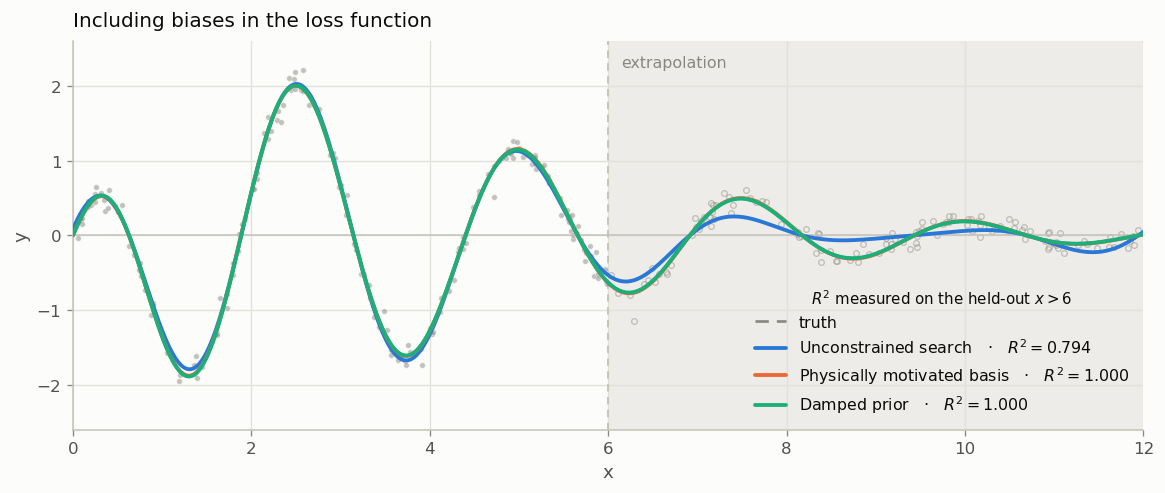

In [41]:
t = time.time()
damped = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["cos", "exp", "log", "sqrt"],
    maxsize=25, niterations=40, random_state=3,
    loss_function=DECAY_LOSS, **REPRO,
)
damped.fit(X_fit, y_fit, variable_names=["x"])

print(f"{time.time() - t:.0f}s   {damped.get_best().equation}")
plot_fits([("Unconstrained search", unconstrained), ("Physically motivated basis", basis), ("Damped prior", damped)],
          x_fit, y_fit, x_out, y_out, title="Including biases in the loss function")

Never told which envelope to use, and it still lands on $\approx 2.8\,x\,e^{-x/2}\cos(2.5x)$ — spelled `x * 2.8 * cos(2.5x) / sqrt(exp(x))`, since $\sqrt{e^{x}}$...

In [46]:
x_bad, y_bad, x_out, y_out = oscillator_data(outliers=True)
X_bad = x_bad.reshape(-1, 1)

squared = PySRRegressor(
    binary_operators=["+", "-", "*", "/"], unary_operators=["sin", "cos", "exp", "log", "sqrt"],
    maxsize=25, niterations=40, random_state=3, **REPRO,
)
squared.fit(X_bad, y_bad, variable_names=["x"])
print(f"{squared.get_best().equation}")

(cos(log(x)) + 1.193855) * cos(x * -2.5049756)


Lets try another 'trick' to see how we can bias the search to be robust to noise. Instead of the usual squared error, we can use a Huber loss, which is quadratic for small residuals but linear for large ones. This way, outliers do not dominate the loss and the search is more robust to noise.

12s   (x * (cos(x + (x / 0.66691744)) / 0.3505015)) / exp(x * 0.50461286)


<lambdifygenerated-63>:2: RuntimeWarning: divide by zero encountered in log
  return (cos(log(x)) + 1.193855)*cos(2.5049756*x)
<lambdifygenerated-63>:2: RuntimeWarning: invalid value encountered in cos
  return (cos(log(x)) + 1.193855)*cos(2.5049756*x)


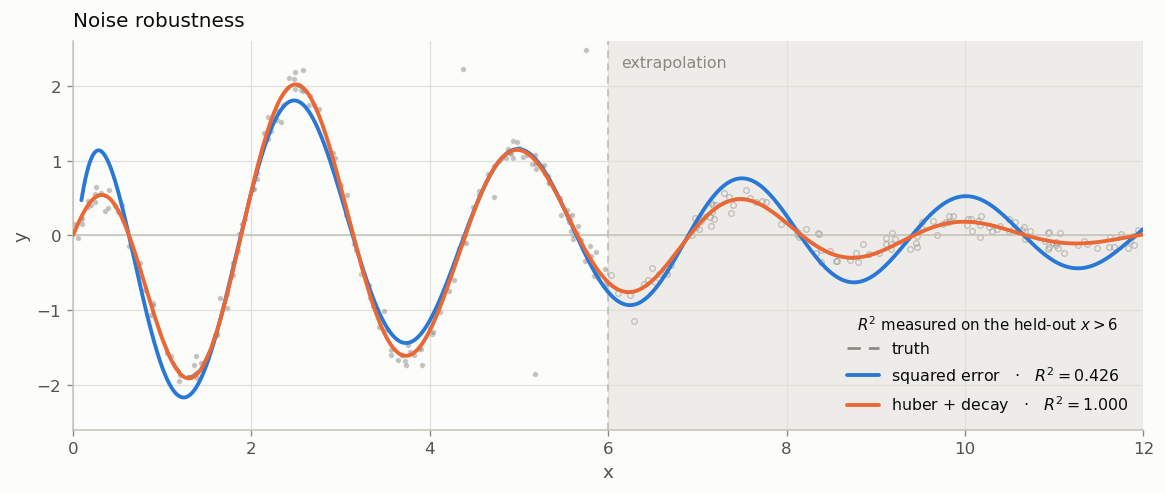

In [48]:
ROBUST_LOSS = """
function robust_loss(tree, dataset::Dataset{T,L}, options)::L where {T,L}
    prediction, ok = eval_tree_array(tree, dataset.X, options)
    !ok && return L(Inf)

    d = abs.(prediction .- dataset.y)
    delta = L(0.3)                       # beyond this a residual is an outlier, not noise
    huber = sum(ifelse.(d .< delta, L(0.5) .* d.^2, delta .* (d .- L(0.5) * delta))) / dataset.n

    far = reshape(T.(collect(12.0:1.0:30.0)), 1, :)
    tail, ok_far = eval_tree_array(tree, far, options)
    !ok_far && return L(Inf)

    return huber + sum(tail.^2) / length(tail)
end
"""

t = time.time()
robust = PySRRegressor(
    binary_operators=["+", "-", "*", "/"], unary_operators=["sin", "cos", "exp"],
    maxsize=25, niterations=40, random_state=3,
    loss_function=ROBUST_LOSS, **REPRO,
    nested_constraints={"sin": {"sin": 0, "cos": 0}, "cos": {"sin": 0, "cos": 0},
                        "exp": {"exp": 0}},
)
robust.fit(X_bad, y_bad, variable_names=["x"])
print(f"{time.time() - t:.0f}s   {robust.get_best().equation}")

plot_fits([("squared error", squared), ("huber + decay", robust)],
          x_bad, y_bad, x_out, y_out, title="Noise robustness")

Same data, same operators, same budget. The only difference is what we told it to minimise.

Three places to put what we know, then: the operators the search may use, the shapes it may build from them, and the number it is trying to make small. The rest of this notebook is that last one, pushed further.

---

## 2. Kepler's third law

Miles told us how the Third Law of Kepler is itself a human-made symbolic regression... Lets see this case.

Lets use the data of the solar system to see if we can recover Kepler's third law.


In [15]:
bodies, a_au, T_yr = kepler_data()
A = a_au.reshape(-1, 1)

kepler_kw = dict(binary_operators=["+", "-", "*", "/"], unary_operators=["sqrt"],
                 niterations=30, maxsize=25, random_state=2, **REPRO)

t = time.time()
mse_fit = PySRRegressor(**kepler_kw)
mse_fit.fit(A, T_yr, variable_names=["a"])
print(f"{time.time() - t:.0f}s   selected: {mse_fit.get_best().equation}")
error_table(mse_fit, "MSE").head(4)   # the rest is in the figure below

5s   selected: ((a - -0.09221804) * ((sqrt(a) * 1.0029187) + -0.034450486)) - 0.055340886


,body,a [AU],T [yr],MSE pred,MSE rel err %
0,Mercury,0.3871,0.2408,0.2272,5.633
1,Venus,0.7233,0.6152,0.6122,0.494
2,Earth,1.0000,1.0000,1.0024,0.244
3,Mars,1.5237,1.8808,1.8895,0.461


Sedna's period is forty-seven thousand times Mercury's, so squared residuals out there swamp everything inside Jupiter's orbit.

In [16]:
mse_exact = np.mean((a_au ** 1.5 - T_yr) ** 2)                # Kepler: T = a^(3/2)
mse_chosen = np.mean((mse_fit.predict(A) - T_yr) ** 2)
print(f"MSE of T = a^1.5        : {mse_exact:12.5f}")
print(f"MSE of the fitted model : {mse_chosen:12.5f}   ({mse_exact / mse_chosen:,.0f}x lower)")
print()
print(f"T = a^1.5 misses Sedna by   {100 * abs(a_au[-1] ** 1.5 - T_yr[-1]) / T_yr[-1]:.2f}%")
print(f"T = a^1.5 misses Mercury by {100 * abs(a_au[0] ** 1.5 - T_yr[0]) / T_yr[0]:.2f}%")

MSE of T = a^1.5        :     26.44008
MSE of the fitted model :      0.00021   (124,574x lower)

T = a^1.5 misses Sedna by   0.16%
T = a^1.5 misses Mercury by 0.02%


Kepler's law reproduces Sedna to a sixth of a percent, and that residual of a few years is enough for MSE to rank the actual law five orders of magnitude worse than a rational function bent around the outer bodies. We care about fractional error; MSE isn't measuring it.

The log-ratio loss from the docs does. The sign term stops the search flipping sign to game the logarithm.

**The tool — `elementwise_loss`**

```python
PySRRegressor(elementwise_loss="l(prediction, target) = (prediction - target)^2", ...)
```

One residual at a time; PySR sums it for us. The string is Julia, so `^` is exponentiation, `abs`/`log`/`sign` are builtins, and `if/else` is allowed.

Reach for this when the change is per-point, and for `loss_function` when it is not.

In [17]:
# This string is Julia rather than Python: ^ is exponentiation and sign() is a builtin.
log_loss = """function loss_fnc(prediction, target)
    scatter_loss = abs(log((abs(prediction)+1e-20) / (abs(target)+1e-20)))
    sign_loss = 10 * (sign(prediction) - sign(target))^2
    return scatter_loss + sign_loss
end"""

t = time.time()
log_fit = PySRRegressor(elementwise_loss=log_loss, **kepler_kw)
log_fit.fit(A, T_yr, variable_names=["a"])
print(f"{time.time() - t:.0f}s   selected: {log_fit.get_best().equation}")
print(f"kink row:  {kink(log_fit).equation}   (score {kink(log_fit).score:.1f})")
error_table(log_fit, "log").head(4)   # same four bodies, for the contrast

4s   selected: ((6.0542527e-5 / ((a / a) - ((a / 1.0044682) / (a + -1.3517331)))) + sqrt(a)) * a
kink row:  a * sqrt(a)   (score 7.8)


,body,a [AU],T [yr],log pred,log rel err %
0,Mercury,0.3871,0.2408,0.2409,0.025
1,Venus,0.7233,0.6152,0.6152,0.006
2,Earth,1.0000,1.0000,1.0000,0.002
3,Mars,1.5237,1.8808,1.8808,0.001


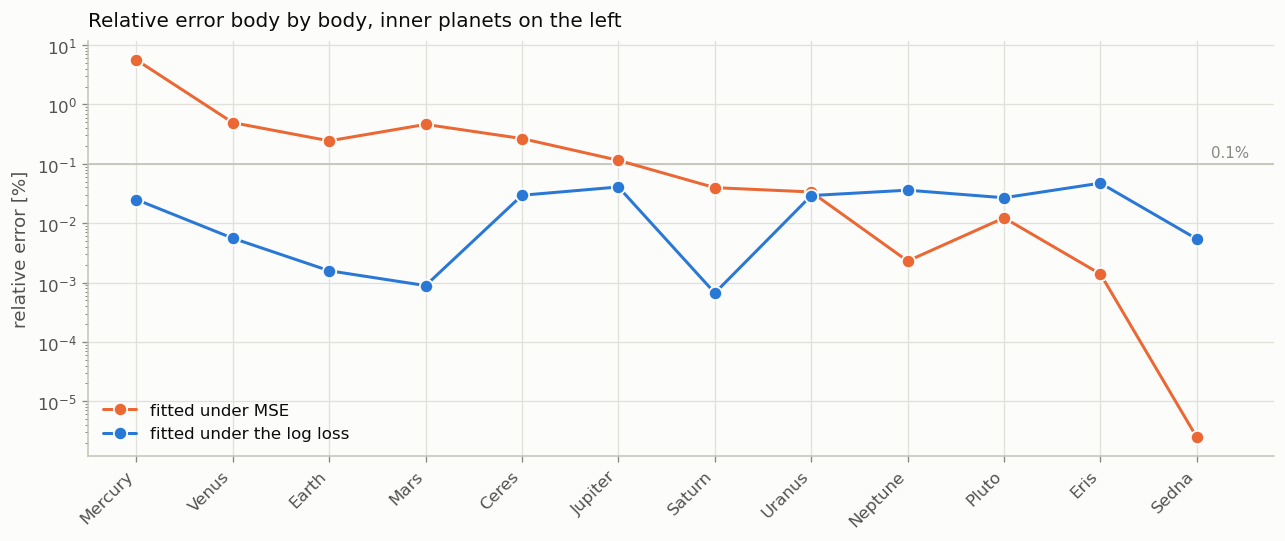

In [18]:
plot_kepler(mse_fit, log_fit)

The two fits are indistinguishable on log-log axes, so the figure shows fractional error instead. MSE trades the inner planets away for the outer ones; the log fit sits within a few hundredths of a percent throughout. The elbow row is `a * sqrt(a)`, which is $a^{3/2}$.

For plain relative error, divide by the target, never the prediction: dividing by the prediction lets evolution win by sending predictions to infinity.

In [19]:
t = time.time()
rel_fit = PySRRegressor(
    elementwise_loss="rel(prediction, target) = ((prediction - target) / target)^2",
    **kepler_kw)
rel_fit.fit(A, T_yr, variable_names=["a"])
print(f"{time.time() - t:.0f}s")
rel_fit.equations_[["complexity", "loss", "score", "equation"]].head(4)

3s


,complexity,loss,score,equation
0,1,7.690740e-01,0.000000,0.36131686
1,3,3.934291e-01,0.335143,a + -0.11927078
2,4,3.131547e-07,14.043714,a * sqrt(a)
3,6,3.092937e-07,0.006203,a * (sqrt(a) + -8.094969e-5)


## 3. Spring-mass energy, and templates

$E(x, v) = \tfrac12 k x^2 + \tfrac12 m v^2$ separates into a function of $x$ plus a function of $v$. Nothing so far has told PySR what the answer looks like; this is the first prior that does.

**The tool — `TemplateExpressionSpec`**

```python
spec = TemplateExpressionSpec(
    "f(x) + g(v)",               # the fixed shape; f and g are the holes
    expressions=["f", "g"],      # what the search is allowed to fill in
    variable_names=["x", "v"],   # names, in the order of X's columns
)
PySRRegressor(expression_spec=spec, ...)
```

The algebra around the holes is structure, not a hypothesis: no candidate can trade it away. Components print with `#1` for their first argument.

In [20]:
x_1, v_1, E_1 = single_rig()

separable = TemplateExpressionSpec("f(x) + g(v)", expressions=["f", "g"],
                                   variable_names=["x", "v"])

t = time.time()
warmup = PySRRegressor(expression_spec=separable, binary_operators=["+", "-", "*"],
                       maxsize=20, niterations=20, random_state=40, **REPRO)
warmup.fit(np.column_stack([x_1, v_1]), E_1, variable_names=["x", "v"])
print(f"{time.time() - t:.0f}s   kink: {kink(warmup).equation}")
warmup.equations_[["complexity", "loss", "score", "equation"]]

11s   kink: f = (#1 + #1) * #1; g = (#1 * 0.75) * #1


,complexity,loss,score,equation
0,2,2.633620e+00,0.000000,f = 0.89792466; g = 1.5767939
1,4,1.271074e+00,0.364248,f = #1 * #1; g = 1.7423178
2,6,6.646108e-01,0.324208,f = #1 * #1; g = #1 * #1
3,8,1.337378e-01,0.801660,f = (#1 * 1.7383102) * #1; g = #1 * #1
4,10,2.517322e-14,14.650561,f = (#1 + #1) * #1; g = (#1 * 0.75) * #1
5,12,2.394206e-14,0.025072,f = #1 * (#1 + #1); g = ((#1 + -3.662307e-8) *...
6,16,2.335733e-14,0.006181,f = #1 * (#1 + #1); g = ((-0.39580727 * (5.052...
7,18,2.232630e-14,0.022573,f = #1 * (#1 * 2.0); g = ((#1 * 0.75) * #1) - ...
8,20,2.182975e-14,0.011246,f = #1 * (2.0 * #1); g = (#1 * (0.75 * #1)) - ...


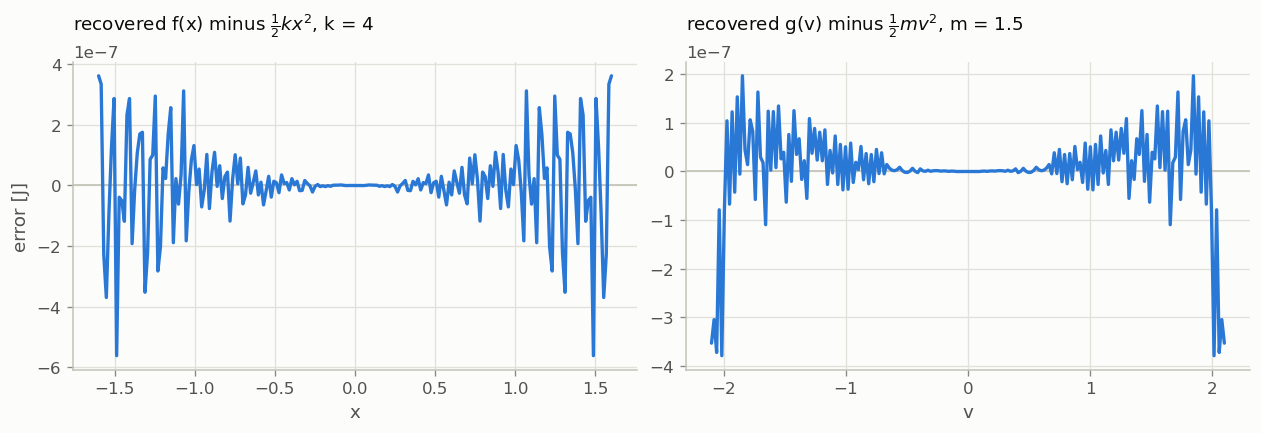

In [21]:
# f and g come back out by slicing the fitted surface: E(x, 0) is f, and E(0, v) is g.
plot_components(warmup, x_1, v_1)

`#1` is the component's first argument. Templates have no `.sympy()` export yet, so reading components out of `equations_` by hand is the workflow. The elbow row gives $f(x) = 2x^2$ and $g(v) = 0.75v^2$, which are $\tfrac12 k$ and $\tfrac12 m$ for $k = 4$, $m = 1.5$.

A free search finds a two-term polynomial like this unaided, so the template bought a guarantee and nothing more. Part B is where it changes the answer.

### Three rigs, and a label that means nothing

Same experiment on three rigs. We get $x$, $v$, the energy and a rig ID, nobody tells us $k$ or $m$, and there is a fourth rig on the bench we would like to say something about.

In [22]:
X_rig, E_rig = rig_data()
pd.DataFrame(X_rig[:6], columns=["x", "v", "rig"]).assign(E=E_rig[:6].round(4))

,x,v,rig,E
0,1.018082,1.657949,1.0,5.3400
1,0.344043,0.543156,2.0,0.2659
2,-0.916639,1.817548,1.0,5.4041
3,-0.748169,1.661497,1.0,4.1600
4,0.373361,0.610149,2.0,0.3255
5,1.273668,0.712337,1.0,4.5630


Obvious first move: pass the rig ID as a third column and let the search work it out. The truth is a polynomial, so plus, minus and times only, stopping at machine precision.

In [23]:
t = time.time()
naive = PySRRegressor(
    binary_operators=["+", "-", "*"], maxsize=32, niterations=400,
    # early_stop_condition is a Julia function string of (loss, complexity).
    early_stop_condition="stop_if(loss, complexity) = loss < 1e-10 && complexity < 32",
    random_state=4, **REPRO,
)
naive.fit(X_rig, E_rig, variable_names=["x", "v", "rig"])
print(f"{time.time() - t:.0f}s")
naive.equations_[["complexity", "loss", "score", "equation"]].tail(4)

112s


,complexity,loss,score,equation
12,25,8.240781e-04,0.677759,((rig + -2.283534) * ((-0.118848234 - rig) * (...
13,27,8.127531e-04,0.006919,((rig + -2.2832518) * (((-0.119882196 - rig) *...
14,29,7.929045e-04,0.012362,(((((rig + -2.2811239) * ((v * (v * 0.6336368)...
15,31,3.934283e-13,10.712035,((((-0.12593225 - rig) * (((x * x) * 1.7500014...


Exact to machine precision on all three rigs it was shown. So what does it say about rig 3?

In [24]:
half_k, half_m = read_coefficients(naive, int(kink(naive).name), np.arange(4.0))

print(f"rig 3:  fitted k = {2 * half_k[3]:+.2f} N/m     true k = {K4:+.2f} N/m")
print(f"        fitted m = {2 * half_m[3]:+.2f} kg      true m = {M4:+.2f} kg")
print("\na negative spring constant and a negative mass: compress this spring and it")
print("hands you energy, and the faster it moves the less kinetic energy it has.")

pd.DataFrame({
    "rig": [0, 1, 2, 3],
    "fitted 1/2 k": half_k.round(4), "true 1/2 k": 0.5 * np.append(K_TRUE, K4),
    "fitted 1/2 m": half_m.round(4), "true 1/2 m": 0.5 * np.append(M_TRUE, M4),
})

rig 3:  fitted k = -8.00 N/m     true k = +3.00 N/m
        fitted m = -2.50 kg      true m = +1.50 kg

a negative spring constant and a negative mass: compress this spring and it
hands you energy, and the faster it moves the less kinetic energy it has.


,rig,fitted 1/2 k,true 1/2 k,fitted 1/2 m,true 1/2 m
0,0,0.5,0.5,0.25,0.25
1,1,2.5,2.5,1.00,1.00
2,2,1.0,1.0,0.50,0.50
3,3,-4.0,1.5,-1.25,0.75


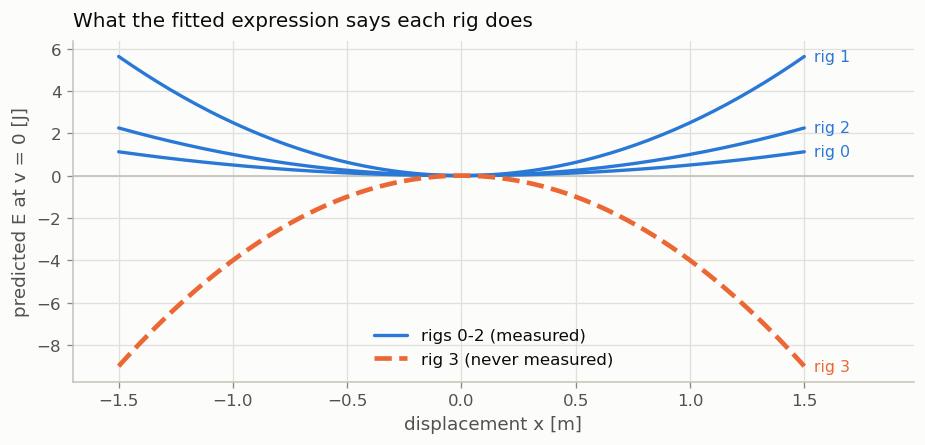

In [25]:
plot_rig_parabolas(naive, int(kink(naive).name))

Three rigs give three values of $\tfrac12 k$, and a quadratic through three points is exact, so the search fitted a polynomial in the rig label. Lagrange interpolation guarantees it reproduces rigs 0 to 2 and nothing constrains it in between or beyond.

The rig ID is an index. Arithmetic on it is meaningless, and a free search has no way to know that, so we take the ability away.

**The tool — `parameters=` inside a template**

```python
TemplateExpressionSpec(
    "p[class] * f(x) + q[class] * g(v)",
    expressions=["f", "g"],
    parameters={"p": 3, "q": 3},              # three fitted constants each
    variable_names=["x", "v", "class"],
)
```

`p[class]` is a per-class constant that gets *fitted* rather than searched, so the class label can only ever be a subscript. The index column must be integers starting at 1, since Julia counts from 1.

In [26]:
# SymbolicRegression.jl wants at least one expression symbol, so `expressions=[]` is
# rejected in 1.5.x. Leaving f and g free costs nothing here; what matters is that
# `class` can now only ever appear as a subscript on p and q.
per_rig = TemplateExpressionSpec(
    "p[class] * f(x) + q[class] * g(v)",
    expressions=["f", "g"],
    parameters={"p": 3, "q": 3},          # three rigs
    variable_names=["x", "v", "class"],
)

X_template = X_rig.copy()
X_template[:, 2] += 1                     # Julia indexes from 1

t = time.time()
templated = PySRRegressor(expression_spec=per_rig, binary_operators=["+", "-", "*"],
                          maxsize=20, niterations=20, random_state=4, **REPRO)
templated.fit(X_template, E_rig, variable_names=["x", "v", "class"])
print(f"{time.time() - t:.0f}s")
templated.equations_[["complexity", "loss", "score", "equation"]]

34s


,complexity,loss,score,equation
0,2,1.639717e+00,0.000000,"f = 1.0435613; g = #1; p = [0.65744525, 3.2881..."
1,4,6.778849e-01,0.441651,"f = #1 * #1; g = 3.2442198; p = [0.5268655, 2...."
2,6,2.775585e-14,15.413276,"f = #1 * #1; g = #1 * #1; p = [0.49999997, 2.5..."
3,8,2.723463e-14,0.009479,"f = (#1 + #1) * #1; g = #1 * #1; p = [0.25, 1...."
4,12,2.676682e-14,0.004332,f = (#1 + #1) * #1; g = #1 + ((#1 * #1) - #1);...


In [27]:
best_t = int(kink(templated).name)
half_k_t, half_m_t = read_coefficients(templated, best_t, np.arange(1.0, 4.0))  # 1-based

# And rig 3? Its class column would index p[4], which does not exist.
try:
    templated.predict(np.array([[1.0, 0.0, 4.0]]), index=best_t)
except Exception as exc:
    print(f"asking for rig 3 -> {type(exc).__name__}: {str(exc).split('.')[0]}")

pd.DataFrame({
    "rig": [0, 1, 2],
    "fitted 1/2 k": half_k_t.round(5), "true 1/2 k": 0.5 * K_TRUE,
    "fitted 1/2 m": half_m_t.round(5), "true 1/2 m": 0.5 * M_TRUE,
})

asking for rig 3 -> ValueError: Failed to evaluate the expression


,rig,fitted 1/2 k,true 1/2 k,fitted 1/2 m,true 1/2 m
0,0,0.5,0.5,0.25,0.25
1,1,2.5,2.5,1.00,1.00
2,2,1.0,1.0,0.50,0.50


Per-rig constants to five digits, and $f$, $g$ come back as $x^2$ and $v^2$. Asking about rig 3 fails outright, which is the honest answer: we have no data on it and the template declines to invent any.

**Try this:** relabel the rigs 10, 20 and 30 and run the free search again. The spurious polynomial returns with different coefficients, which is the tell that it was never about the physics.

## 4. Forces measured, a potential wanted

Templates can differentiate. `D(f, 1)` inside a combine string is $df/dx$, which means we can fit a quantity we never measured by writing down how it relates to one we did.

An anharmonic spring: we can measure the force at any position, but not the potential energy. The physics connecting them is $F = -dV/dx$, so we make that the template and let the search fit $V$.

**The tool — `D()`, a derivative inside a template**

```python
TemplateExpressionSpec(expressions=["V"], variable_names=["x"],
                       combine="dV = D(V, 1); -dV(x)")
```

`D(V, 1)` differentiates component `V` with respect to its first argument and hands back a function, which we then call at `x`. The combine string is Julia and may hold several statements separated by `;`, though not `if/else`.

Scoring happens on `-dV`, so `V` itself is never compared to anything — it is fitted out of data that only contains its slope.

In [28]:
x_pot, F_pot = potential_data()

# The combine string is Julia: define dV as the derivative of V, then evaluate -dV at x.
gradient = TemplateExpressionSpec(expressions=["V"], variable_names=["x"],
                                  combine="dV = D(V, 1); -dV(x)")

t = time.time()
pot = PySRRegressor(expression_spec=gradient, binary_operators=["+", "-", "*"],
                    maxsize=20, niterations=40, random_state=7, **REPRO)
pot.fit(x_pot.reshape(-1, 1), F_pot, variable_names=["x"])
print(f"{time.time() - t:.0f}s")
pot.equations_[["complexity", "loss", "score", "equation"]]

37s


,complexity,loss,score,equation
0,1,56.935104,0.000000,V = 0.39730215
1,3,27.612577,0.361820,V = #1 * #1
2,5,1.320278,1.520214,V = (#1 * 3.2007523) * #1
3,7,1.319554,0.000274,V = ((#1 * 3.1998816) - 0.026981425) * #1
4,9,1.316665,0.001096,V = (((#1 * -0.0111747375) - -3.1978233) * #1)...
5,11,0.002502,3.132903,V = (#1 * (((#1 * 0.24993905) * #1) - -2.00139...
6,13,0.002501,0.000111,V = ((((#1 * 0.24994583) + 0.0001387242) * #1)...
7,19,0.002501,0.000028,V = (#1 + 0.0011047445) * (((((((#1 * -0.74981...


Every row on that front is a candidate $V$, scored by how well its derivative matches forces we measured.

recovered V(x) = x**2*(0.24993905*x**2 + 2.0013952)
true      V(x) = 2*x**2 + 0.25*x**4


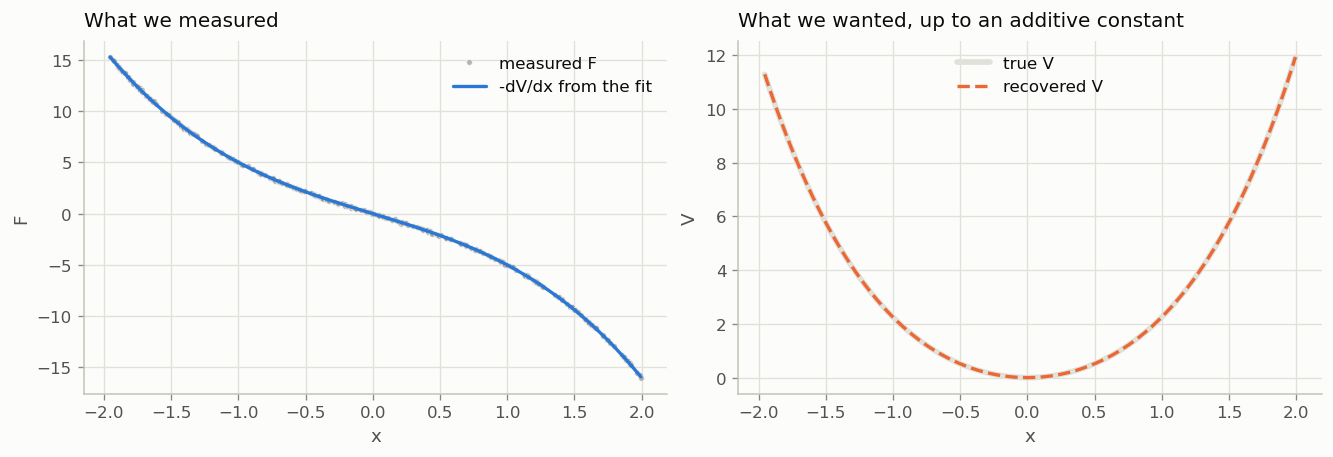

In [29]:
expr, _ = read_potential(pot, int(kink(pot).name))
print(f"recovered V(x) = {expr}")
print(f"true      V(x) = 2*x**2 + 0.25*x**4")
plot_potential(pot, x_pot, F_pot, int(kink(pot).name))

The potential comes back from data that only ever contained its slope.

Note what is missing: an additive constant. Nothing in the force data can pin one down, since it differentiates away, which is exactly right physically because only potential differences are measurable. The right-hand panel is drawn with the fit shifted to $V(0) = 0$ for that reason.

## 5. Distilling a network we already trained

The far end of the range: no structure to offer at all, so fit something flexible and ask it what function it learned.

Miles co-authored SymTorch and very likely showed you the idea, so this is our turn to run the wrap, distill and switch loop. Separate install, separate mental model, its own short setup.

**The tool — SymTorch**

```python
net.mlp = SymbolicModel(net.mlp, block_name="Sequential")   # wraps in place
fits = net.mlp.distill(X, parent_model=net, sr_params=SR_PARAMS)
net.mlp.switch_to_symbolic(complexity=[9])   # the equation now runs in forward()
net.mlp.switch_to_block()                    # and back to the network
```

`distill` returns one `PySRRegressor` per output of the wrapped block. Always pass `sr_params`: the default is 400 iterations.

In [30]:
if importlib.util.find_spec("symtorch") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch-symbolic"], check=True)

import torch
import torch.nn as nn
from symtorch import SymbolicModel

print(f"torch {torch.__version__}, symtorch imported")
print("DEFAULT_SR_PARAMS niterations =", SymbolicModel.DEFAULT_SR_PARAMS["niterations"])

torch 2.10.0, symtorch imported
DEFAULT_SR_PARAMS niterations = 400


Four hundred iterations by default, minutes rather than seconds, so always pass your own `sr_params`. `.distill()` runs PySR internally and has its own first-call cost, so spend it on something throwaway.

In [31]:
SR_PARAMS = dict(binary_operators=["+", "*", "/"], unary_operators=[], niterations=30,
                 deterministic=True, parallelism="serial", random_state=6,
                 verbosity=0, progress=False)

t = time.time()
_prewarm = SymbolicModel(nn.Sequential(nn.Linear(1, 4), nn.ReLU(), nn.Linear(4, 1)),
                         block_name="prewarm")
_ = _prewarm.distill(torch.randn(30, 1), save_path="symtorch_runs",
                     sr_params={**SR_PARAMS, "niterations": 2})
print(f"first .distill(): {time.time() - t:.0f}s")

first .distill(): 4s


The target has a force-law flavour, $F(r, s) = 1/r^2 + 0.3\,s$. We pretend we can measure $F$, $r$ and $s$ and have no idea about the $1/r^2$.

In [32]:
RECOVER = False        # flip to True to load assets/problem6_mlp.pt instead of training


class ForceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(2, 32), nn.ReLU(),
                                 nn.Linear(32, 32), nn.ReLU(),
                                 nn.Linear(32, 1))

    def forward(self, x):
        return self.mlp(x)


X_tr, y_tr = force_law_data(400, seed=6)
X_te, y_te = force_law_data(400, seed=7)
X_tr_t, y_tr_t = torch.tensor(X_tr), torch.tensor(y_tr)
X_te_t, y_te_t = torch.tensor(X_te), torch.tensor(y_te)

torch.manual_seed(6)
net = ForceNet()

if RECOVER and (ASSETS / "problem6_mlp.pt").exists():
    net.load_state_dict(
        torch.load(ASSETS / "problem6_mlp.pt", weights_only=False)["state_dict"])
    print("loaded assets/problem6_mlp.pt instead of training")
else:
    if RECOVER:
        print("RECOVER=True but assets/problem6_mlp.pt is missing, so training instead")
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    for _ in range(400):
        opt.zero_grad()
        train_loss = nn.functional.mse_loss(net(X_tr_t), y_tr_t)
        train_loss.backward()
        opt.step()
    print(f"trained 400 epochs: train mse {train_loss.item():.3e}")

with torch.no_grad():
    mlp_mse = nn.functional.mse_loss(net(X_te_t), y_te_t).item()
print(f"MLP held-out test mse {mlp_mse:.3e}")

trained 400 epochs: train mse 3.807e-04
MLP held-out test mse 5.992e-04


Wrapping replaces the submodule in place, so the network keeps working and now also describes itself. `net.mlp.show_symbolic_expression()` prints the front per output dimension.

In [33]:
net.mlp = SymbolicModel(net.mlp, block_name="Sequential")

t = time.time()
distilled = net.mlp.distill(X_tr_t, parent_model=net, sr_params=SR_PARAMS,
                            save_path="symtorch_runs")
print(f"distill: {time.time() - t:.0f}s")
distilled[0].equations_[["complexity", "loss", "score", "equation"]]

distill: 16s


,complexity,loss,score,equation
0,1,0.761771,0.000000e+00,0.9832491
1,3,0.209628,6.451569e-01,1.2424767 / x0
2,5,0.029702,9.770589e-01,1.0047475 / (x0 * x0)
3,7,0.029636,1.104461e-03,(1.0120033 / (x0 * x0)) + -0.012420696
4,9,0.000377,2.181677e+00,(x1 / 3.332981) + ((0.9992295 / x0) / x0)
5,11,0.000363,1.994166e-02,((1.013465 / x0) / (x0 + 0.009584047)) + (x1 *...
6,13,0.000347,2.206542e-02,((x1 / 3.3346832) + -0.0121766925) + ((1.04350...
7,15,0.000329,2.615351e-02,(x1 * 0.3002809) + ((x0 + 0.013382574) / ((x0 ...
8,17,0.000297,5.209400e-02,(((x0 + 0.06274043) / ((x0 * (x0 * x0)) + 0.01...
9,19,0.000267,5.351081e-02,(x0 * (0.88461244 / (((x0 + -0.119688235) * (x...


Now we take the elbow row and swap it in for the network.

In [34]:
pick = int(kink(distilled[0]).complexity)
net.mlp.switch_to_symbolic(complexity=[pick])

with torch.no_grad():
    sym_pred = net(X_te_t).numpy()
    sym_mse = nn.functional.mse_loss(net(X_te_t), y_te_t).item()

print(f"swapped in complexity {pick}: {kink(distilled[0]).equation}")
print(f"MLP      test mse: {mlp_mse:.3e}")
print(f"symbolic test mse: {sym_mse:.3e}   ({mlp_mse / sym_mse:,.0f}x lower)")

swapped in complexity 9: (x1 / 3.332981) + ((0.9992295 / x0) / x0)
MLP      test mse: 5.992e-04
symbolic test mse: 1.039e-06   (577x lower)


back on the network: 5.992e-04


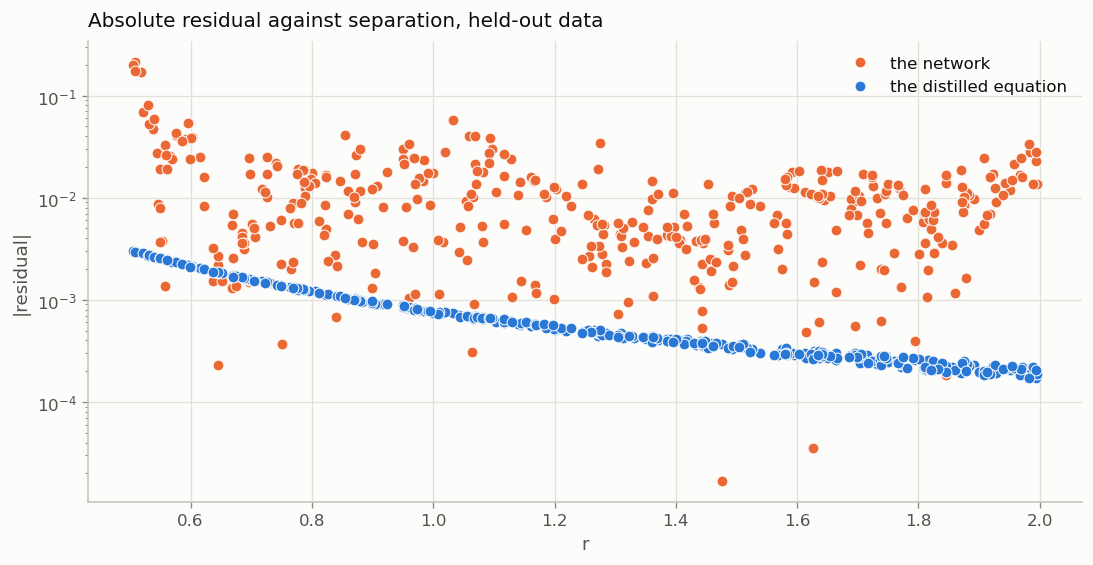

In [35]:
net.mlp.switch_to_block()          # restores the network exactly, not switch_to_mlp
with torch.no_grad():
    mlp_pred = net(X_te_t).numpy()
    print(f"back on the network: {nn.functional.mse_loss(net(X_te_t), y_te_t).item():.3e}")

plot_distillation(X_te, y_te, mlp_pred, sym_pred)

The equation beats the network it came from on held-out data by better than two orders of magnitude. The network built $1/r^2$ out of ReLUs and carried that error into every prediction; the equation simply is $1/r^2$, so distillation threw the interpolation error away along with the 1,185 parameters.

This only happens when the true function lives inside the search space, so read it as a diagnostic rather than a promise: when a distilled equation beats its own teacher out of sample, there is a good chance it is the real thing.

Two caveats. SymTorch is new, released this year with an empty issue tracker, so there is no troubleshooting trail yet. And `switch_to_symbolic()` needs sympy 1.14+ for the torch lambdify printer; on 1.13.x it warns and quietly leaves the network in place, so a clean-looking run is not evidence anything was swapped.

## Where that leaves us

Every target this afternoon had a known answer, which is the only way to tell whether a prior helped or merely changed something.

One ordering worth taking away: constrain the search space before writing a custom loss, and try a template before writing a custom objective. Constraints cost almost nothing and fix a surprising share of bad searches, whereas a template changes what the search can express at all, which is the only reason the three-rig case worked. And when there is no structure to write down, train something flexible and distil it.

Let's take five minutes. Session 2 is a shorter practice round on data where nobody knows the answer in advance.

### Appendix: checking the fallback checkpoint

assets/problem6_mlp.pt` is what `RECOVER = True` loads, and it should reproduce the network we trained above exactly.

In [36]:
if (ASSETS / "problem6_mlp.pt").exists():
    ckpt = torch.load(ASSETS / "problem6_mlp.pt", weights_only=False)
    spare = ForceNet()
    spare.load_state_dict(ckpt["state_dict"])
    with torch.no_grad():
        spare_mse = nn.functional.mse_loss(spare(X_te_t), y_te_t).item()
    print(f"checkpoint test mse {spare_mse:.3e} (recorded {ckpt['test_mse']:.3e}); "
          f"the network trained above scored {mlp_mse:.3e}")
else:
    print("assets/problem6_mlp.pt not found, so RECOVER=True will not work in this copy")

checkpoint test mse 5.992e-04 (recorded 5.992e-04); the network trained above scored 5.992e-04
